# 09 DenseNet121 + CLAHE + ordinal loss
Compared with DenseNet121 + CE + CLAHE, the loss function is changed from standard CrossEntropyLoss to OrdinalCrossEntropyLoss.

Purpose:
- keep the contrast-enhancement benefit of CLAHE
- reduce ordinal misclassification
- improve MAE and QWK
- reduce distant errors





In [13]:
EXPERIMENT_NAME = "densenet121_clahe_ordinal_loss"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

ORDINAL_ALPHA = 0.2

print("Experiment:", EXPERIMENT_NAME)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Monitor metric:", MONITOR_METRIC)
print("CLAHE clip limit:", CLAHE_CLIP_LIMIT)
print("CLAHE tile grid size:", CLAHE_TILE_GRID_SIZE)
print("Ordinal alpha:", ORDINAL_ALPHA)



Experiment: densenet121_clahe_ordinal_loss
Image size: 224
Batch size: 32
Learning rate: 0.0001
Max epochs: 30
Patience: 7
Monitor metric: qwk
CLAHE clip limit: 2.0
CLAHE tile grid size: (8, 8)
Ordinal alpha: 0.2


In [14]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [15]:
import importlib
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils.train_utils
import utils.dataset_clahe
import models.loss_funcs

importlib.reload(utils.train_utils)
importlib.reload(utils.dataset_clahe)
importlib.reload(models.loss_funcs)

from utils.dataset_clahe import get_dataloaders, print_dataset_info
from models.densenet import get_densenet121, count_trainable_parameters
from models.loss_funcs import OrdinalCrossEntropyLoss
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics, get_confusion_matrix



In [16]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cuda
Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [17]:
# dataloader
from utils.dataset_clahe import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid_size=CLAHE_TILE_GRID_SIZE,
)


print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information with CLAHE
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [18]:
# loss and optimizer CrossEntropyLoss
criterion = OrdinalCrossEntropyLoss(
    num_classes=NUM_CLASSES,
    alpha=ORDINAL_ALPHA
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)




Image batch shape: torch.Size([32, 3, 224, 224])
Image min: -2.1179039478302
Image max: 2.640000104904175


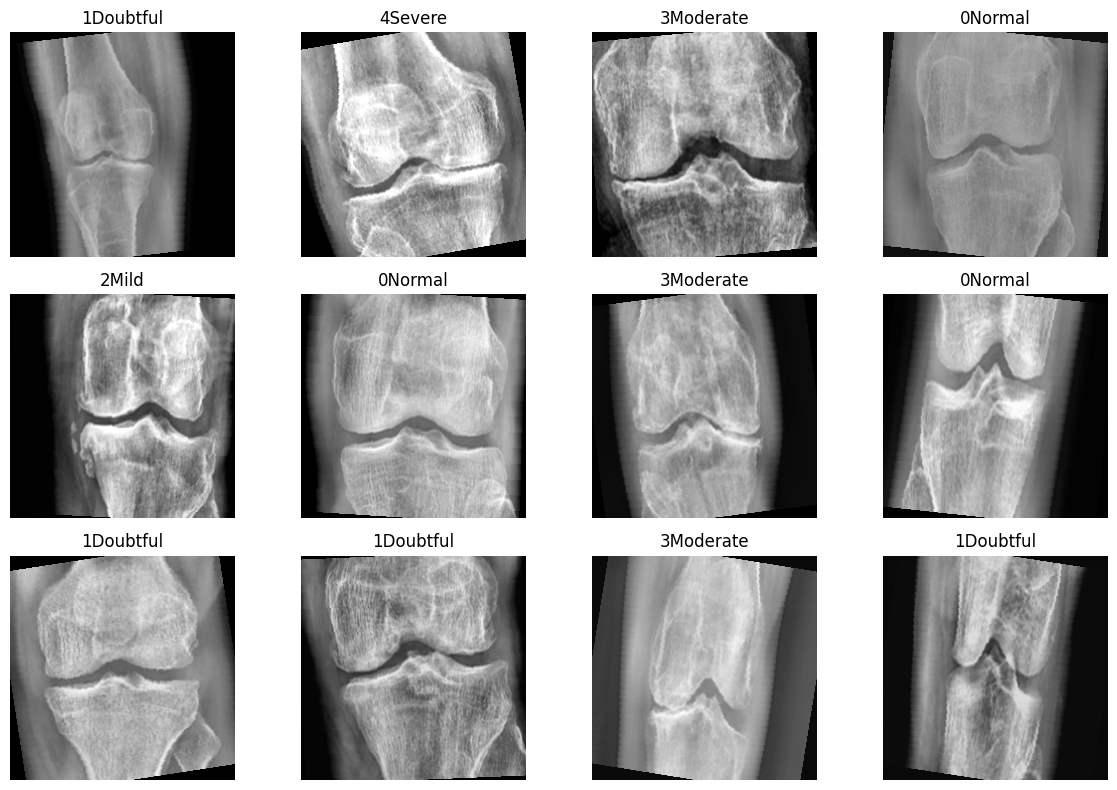

In [19]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Image min:", images.min().item())
print("Image max:", images.max().item())

import torch
import matplotlib.pyplot as plt

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor):
    img = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = torch.clamp(img, 0, 1)
    return img

plt.figure(figsize=(12, 8))

for i in range(12):
    img = denormalize(images[i])
    label = labels[i].item()

    plt.subplot(3, 4, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()




## create densenet

In [20]:
from utils.train_utils import train_model

SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)





Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.5765 | Train Acc: 0.4697 | Train Macro F1: 0.4216 | Train QWK: 0.4765
Val Loss:   1.1822 | Val Acc:   0.6096 | Val Macro F1: 0.5035 | Val QWK:   0.7040 | Val MAE:   0.5959
New best model found at epoch 1.
Best val qwk: 0.7040
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_clahe_ordinal_loss.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1683 | Train Acc: 0.9512 | Train Macro F1: 0.9485 | Train QWK: 0.9679
Val Loss:   0.7406 | Val Acc:   0.7945 | Val Macro F1: 0.7661 | Val QWK:   0.8921 | Val MAE:   0.2808
No improvement in val qwk. Patience: 6/7

Epoch 18/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1569 | Train Acc: 0.9482 | Train Macro F1: 0.9450 | Train QWK: 0.9709
Val Loss:   0.6032 | Val Acc:   0.8288 | Val Macro F1: 0.8172 | Val QWK:   0.9194 | Val MAE:   0.2123
No improvement in val qwk. Patience: 7/7

Early stopping triggered
Best epoch: 11
Best val qwk: 0.9307


In [21]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()

,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
13,14,0.168492,0.930689,11,2,0.947266,0.947769,0.947246,0.070312,0.971564,...,0.739673,0.729702,0.335616,0.874979,40,33,7,0.273973,0.226027,0.047945
14,15,0.157242,0.640587,11,3,0.958008,0.954835,0.957874,0.061523,0.972269,...,0.792469,0.801687,0.246575,0.905239,28,22,6,0.191781,0.150685,0.041096
15,16,0.139149,0.716326,11,4,0.958008,0.952913,0.957947,0.054688,0.978452,...,0.779437,0.787707,0.273973,0.892272,32,26,6,0.219178,0.178082,0.041096
16,17,0.168348,0.740628,11,5,0.951172,0.948531,0.951237,0.070312,0.967917,...,0.766090,0.778622,0.280822,0.892052,30,21,9,0.205479,0.143836,0.061644
17,18,0.156871,0.603156,11,6,0.948242,0.945004,0.948422,0.070312,0.970906,...,0.817205,0.827359,0.212329,0.919428,25,21,4,0.171233,0.143836,0.027397


## best epoch 

In [22]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                  11.000000
val_loss                0.632678
val_accuracy            0.849315
val_macro_f1            0.836658
val_weighted_f1         0.852365
val_mae                 0.184932
val_qwk                 0.930718
val_adjacent_errors    18.000000
val_distant_errors      4.000000
Name: 10, dtype: float64


## train model

In [23]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / "densenet121_ce_clahe_ordinal.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10,
    save_path=SAVE_PATH,
    monitor_metric="qwk",
)



Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1793 | Train Acc: 0.9512 | Train Macro F1: 0.9470 | Train QWK: 0.9765
Val Loss:   0.6658 | Val Acc:   0.8014 | Val Macro F1: 0.7910 | Val QWK:   0.9061 | Val MAE:   0.2466
New best model found at epoch 1.
Best val qwk: 0.9061
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ce_clahe.pth

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1104 | Train Acc: 0.9697 | Train Macro F1: 0.9703 | Train QWK: 0.9787
Val Loss:   0.7674 | Val Acc:   0.8425 | Val Macro F1: 0.8323 | Val QWK:   0.9191 | Val MAE:   0.2055
No improvement in val qwk. Patience: 1/7

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0972 | Train Acc: 0.9707 | Train Macro F1: 0.9676 | Train QWK: 0.9850
Val Loss:   0.6028 | Val Acc:   0.8493 | Val Macro F1: 0.8403 | Val QWK:   0.9248 | Val MAE:   0.1918
No improvement in val qwk. Patience: 2/7


save history

In [24]:
history_path = PROJECT_ROOT / "outputs" / "results" / "densenet121_ce_clahe_ordinal_loss_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.179346,0.665792,0,0,0.951172,0.947020,0.951252,0.062500,0.976472,...,0.790969,0.803630,0.246575,0.906121,29,24,5,0.198630,0.164384,0.034247
1,2,0.156708,0.684104,1,0,0.962891,0.959602,0.963028,0.048828,0.980909,...,0.809865,0.813137,0.232877,0.911130,27,22,5,0.184932,0.150685,0.034247
2,3,0.189073,0.603726,2,0,0.944336,0.944444,0.944492,0.067383,0.976210,...,0.812444,0.823444,0.212329,0.922759,25,20,5,0.171233,0.136986,0.034247
3,4,0.139557,0.650472,3,0,0.955078,0.949018,0.955074,0.061523,0.974679,...,0.824492,0.827616,0.212329,0.919383,25,21,4,0.171233,0.143836,0.027397
4,5,0.163900,0.815926,3,1,0.943359,0.938302,0.943528,0.080078,0.964224,...,0.782972,0.796052,0.280822,0.885518,29,21,8,0.198630,0.143836,0.054795
5,6,0.150611,0.693691,3,2,0.955078,0.951414,0.955088,0.054688,0.980986,...,0.778863,0.791658,0.280822,0.890432,30,21,9,0.205479,0.143836,0.061644
6,7,0.133589,0.712026,3,3,0.960938,0.959320,0.961253,0.052734,0.978914,...,0.816185,0.823290,0.226027,0.911814,25,19,6,0.171233,0.130137,0.041096
7,8,0.127874,0.635090,3,4,0.963867,0.965770,0.963919,0.050781,0.978017,...,0.793852,0.813678,0.212329,0.924838,26,22,4,0.178082,0.150685,0.027397
8,9,0.110428,0.767406,8,0,0.969727,0.970313,0.969750,0.045898,0.978702,...,0.832325,0.840575,0.205479,0.919106,23,18,5,0.157534,0.123288,0.034247
9,10,0.097150,0.602761,8,1,0.970703,0.967631,0.970784,0.039062,0.984952,...,0.840324,0.848546,0.191781,0.924792,22,18,4,0.150685,0.123288,0.027397


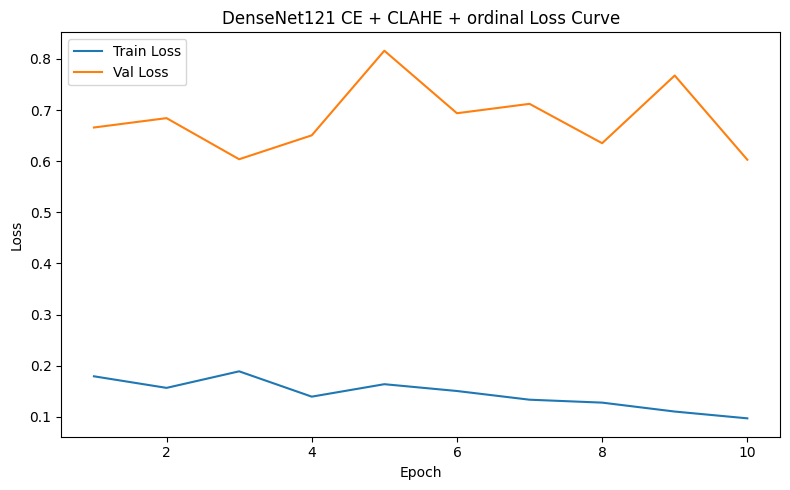

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_clahe_ordinal_loss.png


In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 CE + CLAHE + ordinal Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_clahe_ordinal_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [26]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.8219
macro_f1: 0.7939
weighted_f1: 0.8137
mae: 0.2123
qwk: 0.9248
total_errors: 26
adjacent_errors: 22
distant_errors: 4
total_error_rate: 0.1781
adjacent_error_rate: 0.1507
distant_error_rate: 0.0274


In [27]:
from utils.metrics import get_classification_report
import pandas as pd


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="CLAHE + Ordinal Test Metrics")

test_metrics_df = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "loss": test_loss,
    "clahe_clip_limit": CLAHE_CLIP_LIMIT,
    "clahe_tile_grid_size": str(CLAHE_TILE_GRID_SIZE),
    "ordinal_alpha": ORDINAL_ALPHA,
    **test_metrics
}])

test_metrics_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_test_metrics.csv"
test_metrics_path.parent.mkdir(parents=True, exist_ok=True)

test_metrics_df.to_csv(test_metrics_path, index=False)

test_metrics_df


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

CLAHE + Ordinal Test Metrics
accuracy: 0.7551
macro_f1: 0.7346
weighted_f1: 0.7478
mae: 0.3401
qwk: 0.8384
total_errors: 72
adjacent_errors: 55
distant_errors: 17
total_error_rate: 0.2449
adjacent_error_rate: 0.1871
distant_error_rate: 0.0578


,experiment,loss,clahe_clip_limit,clahe_tile_grid_size,ordinal_alpha,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,total_error_rate,adjacent_error_rate,distant_error_rate
0,densenet121_clahe_ordinal_loss,0.9323,2.0,"(8, 8)",0.2,0.755102,0.734597,0.747792,0.340136,0.838367,72,55,17,0.244898,0.187075,0.057823


In [28]:
#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)

              precision    recall  f1-score   support

     0Normal       0.79      0.96      0.87        91
   1Doubtful       0.70      0.66      0.68        88
       2Mild       0.64      0.55      0.59        38
   3Moderate       0.73      0.91      0.81        35
     4Severe       1.00      0.57      0.73        42

    accuracy                           0.76       294
   macro avg       0.77      0.73      0.73       294
weighted avg       0.77      0.76      0.75       294



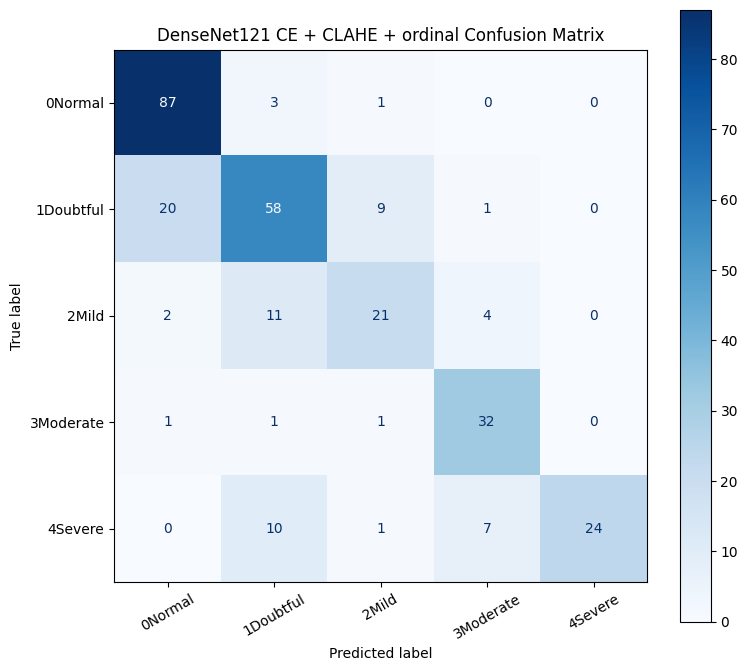

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_clahe_ordinal_confusion_matrix.png


In [29]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 CE + CLAHE + ordinal Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_clahe_ordinal_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
